In [ ]:
# ===== IMPORTAR LIBRERÍAS NECESARIAS =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, ConfusionMatrixDisplay, classification_report)

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import class_weight

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
# ===== IMPORTAR LIBRERÍAS DE PYSPARK =====
from pyspark.sql import SparkSession  # Para crear y manejar sesiones de Spark
from pyspark.sql import functions as F  # Funciones de transformación de DataFrames
from pyspark.sql import types as T  # Tipos de datos de Spark
from pyspark.sql import Window  # Para funciones de ventana (window functions)

# ===== CREAR SESIÓN DE SPARK =====
# Inicializar la sesión de Spark con un nombre de aplicación
spark = SparkSession.builder \
    .appName("Pract2_PySpark") \
    .getOrCreate()

# Verificar la versión de Spark instalada
print("Versión de Spark:", spark.version)

# Obtener el contexto de Spark (SparkContext) para operaciones de bajo nivel
sc = spark.sparkContext

# ===== DEFINIR RUTA DE DATOS =====
# Ruta donde están almacenados los archivos CSV y Parquet
DATA_PATH = "/home/FinPlus/work/data_tratada/"

Versión de Spark: 4.0.1


In [ ]:
# ===== LEEMOS EL ARCHIVO DE LA TABLA CONJUNTA =====
df = (spark.read.option("header", "true").option('delimiter',',')
                     .csv(DATA_PATH + 'client_beh.csv'))

In [ ]:
df.show(10,0)

+------------+----------------------+-----------------+------+------------+--------------+-----------+---------------------+--------------+--------------+------------+------------+-------------+--------------+-----------+-----------------+-------+-----------+----------------+-----------------+------------------+---------------------+------------------+----------+--------------+----------+--------------------------+--------+---------------------+------------------------+------------------------+------------------------+---------------------------+---------------------------+---------------------------+-----------------------+-----------------------+-----------------------+----------------------+----------------------+-------------------+---------------------+-----------------+-------------------+----------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+----------

In [ ]:
# ===== CAMBIAMOS EL TIPO DE DATO DE LAS COLUMNAS =====
NewDataTypes = ['NON_COMPLIANT_CONTRACT',
 'TOTAL_INCOME',
 'AMOUNT_PRODUCT',
 'INSTALLMENT',
 'REGION_SCORE',
 'AGE_IN_YEARS',
 'JOB_SENIORITY',
 'HOME_SENIORITY',
 'LAST_UPDATE',
 'CAR_AGE',
 'FAMILY_SIZE',
 'REACTIVE_SCORING',
 'PROACTIVE_SCORING',
 'BEHAVIORAL_SCORING',
 'DAYS_LAST_INFO_CHANGE',
 'NUMBER_OF_PRODUCTS',
 'DIGITAL_CLIENT',
 'NUM_PREVIOUS_LOAN_APP',
 'LOAN_ANNUITY_PAYMENT_MAX',
 'LOAN_ANNUITY_PAYMENT_MIN',
 'LOAN_ANNUITY_PAYMENT_SUM',
 'LOAN_APPLICATION_AMOUNT_MAX',
 'LOAN_APPLICATION_AMOUNT_MIN',
 'LOAN_APPLICATION_AMOUNT_SUM',
 'LOAN_CREDIT_GRANTED_MAX',
 'LOAN_CREDIT_GRANTED_MIN',
 'LOAN_CREDIT_GRANTED_SUM',
 'LOAN_VARIABLE_RATE_MAX',
 'LOAN_VARIABLE_RATE_MIN',
 'NUM_STATUS_ANNULLED',
 'NUM_STATUS_AUTHORIZED',
 'NUM_STATUS_DENIED',
 'NUM_STATUS_NOT_USED',
 'NUM_FLAG_INSURED',
 'CREDICT_CARD_BALANCE',
 'CREDIT_CARD_LIMIT',
 'CREDIT_CARD_DRAWINGS_ATM',
 'CREDIT_CARD_DRAWINGS',
 'CREDIT_CARD_DRAWINGS_POS',
 'CREDIT_CARD_DRAWINGS_OTHER',
 'CREDIT_CARD_PAYMENT',
 'NUMBER_DRAWINGS_ATM',
 'NUMBER_DRAWINGS',
 'NUMBER_INSTALMENTS']

for i in NewDataTypes:
    df = df.withColumn(i, F.col(i).cast('float'))

df.printSchema()

root
 |-- CLIENT_ID: string (nullable = true)
 |-- NON_COMPLIANT_CONTRACT: float (nullable = true)
 |-- NAME_PRODUCT_TYPE: string (nullable = true)
 |-- GENDER: string (nullable = true)
 |-- TOTAL_INCOME: float (nullable = true)
 |-- AMOUNT_PRODUCT: float (nullable = true)
 |-- INSTALLMENT: float (nullable = true)
 |-- EDUCATION: string (nullable = true)
 |-- MARITAL_STATUS: string (nullable = true)
 |-- HOME_SITUATION: string (nullable = true)
 |-- REGION_SCORE: float (nullable = true)
 |-- AGE_IN_YEARS: float (nullable = true)
 |-- JOB_SENIORITY: float (nullable = true)
 |-- HOME_SENIORITY: float (nullable = true)
 |-- LAST_UPDATE: float (nullable = true)
 |-- OWN_INSURANCE_CAR: string (nullable = true)
 |-- CAR_AGE: float (nullable = true)
 |-- FAMILY_SIZE: float (nullable = true)
 |-- REACTIVE_SCORING: float (nullable = true)
 |-- PROACTIVE_SCORING: float (nullable = true)
 |-- BEHAVIORAL_SCORING: float (nullable = true)
 |-- DAYS_LAST_INFO_CHANGE: float (nullable = true)
 |-- NUMB

In [ ]:
# ===== MIRAMOS LA DIFERENCIA DE CARGA DE LAS DOS VARIABLES CATEGÓRICAS =====
df.groupBy('NON_COMPLIANT_CONTRACT').count().show()

+----------------------+------+
|NON_COMPLIANT_CONTRACT| count|
+----------------------+------+
|                   1.0| 13236|
|                   0.0|149741|
+----------------------+------+



In [ ]:
# ===== CONVERTIMOS LA TABLA DE SPARK A PANDAS PARA TRABAJAR CON SKLEARN =====
df_pandas = df.toPandas()

In [ ]:
df_pandas.head()

,CLIENT_ID,NON_COMPLIANT_CONTRACT,NAME_PRODUCT_TYPE,GENDER,TOTAL_INCOME,AMOUNT_PRODUCT,INSTALLMENT,EDUCATION,MARITAL_STATUS,HOME_SITUATION,...,CREDIT_CARD_LIMIT,CREDIT_CARD_DRAWINGS_ATM,CREDIT_CARD_DRAWINGS,CREDIT_CARD_DRAWINGS_POS,CREDIT_CARD_DRAWINGS_OTHER,CREDIT_CARD_PAYMENT,NUMBER_DRAWINGS_ATM,NUMBER_DRAWINGS,NUMBER_INSTALMENTS,B_CURRENCY
0,ES182100008D,0.0,PRODUCT 1,M,1188.0,5885.950195,330.209991,Secondary,Married,House,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,euros
1,ES182100021X,0.0,PRODUCT 2,F,972.0,3240.000000,162.000000,Secondary,Married,House,...,8100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,euros
2,ES182100030R,0.0,PRODUCT 1,F,1080.0,2700.000000,132.889999,Secondary,Married,House,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,euros
3,ES182100032D,0.0,PRODUCT 1,M,1350.0,3924.290039,285.929993,Secondary,Married,House,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,euros
4,ES182100054X,0.0,PRODUCT 1,F,1188.0,3127.679932,322.059998,Secondary,Married,House,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,euros


In [ ]:
# ===== REALIZAMOS LA ESCALA Y EL ONEHOT ENCODER DE LOS DATOS =====
numericas = [
 'TOTAL_INCOME',
 'AMOUNT_PRODUCT',
 'INSTALLMENT',
 'REGION_SCORE',
 'AGE_IN_YEARS',
 'JOB_SENIORITY',
 'HOME_SENIORITY',
 'LAST_UPDATE',
 'CAR_AGE',
 'FAMILY_SIZE',
 'REACTIVE_SCORING',
 'PROACTIVE_SCORING',
 'BEHAVIORAL_SCORING',
 'DAYS_LAST_INFO_CHANGE',
 'NUMBER_OF_PRODUCTS',
 'DIGITAL_CLIENT',
 'NUM_PREVIOUS_LOAN_APP',
 'LOAN_ANNUITY_PAYMENT_MAX',
 'LOAN_ANNUITY_PAYMENT_MIN',
 'LOAN_ANNUITY_PAYMENT_SUM',
 'LOAN_APPLICATION_AMOUNT_MAX',
 'LOAN_APPLICATION_AMOUNT_MIN',
 'LOAN_APPLICATION_AMOUNT_SUM',
 'LOAN_CREDIT_GRANTED_MAX',
 'LOAN_CREDIT_GRANTED_MIN',
 'LOAN_CREDIT_GRANTED_SUM',
 'LOAN_VARIABLE_RATE_MAX',
 'LOAN_VARIABLE_RATE_MIN',
 'NUM_STATUS_ANNULLED',
 'NUM_STATUS_AUTHORIZED',
 'NUM_STATUS_DENIED',
 'NUM_STATUS_NOT_USED',
 'NUM_FLAG_INSURED',
 'CREDICT_CARD_BALANCE',
 'CREDIT_CARD_LIMIT',
 'CREDIT_CARD_DRAWINGS_ATM',
 'CREDIT_CARD_DRAWINGS',
 'CREDIT_CARD_DRAWINGS_POS',
 'CREDIT_CARD_DRAWINGS_OTHER',
 'CREDIT_CARD_PAYMENT',
 'NUMBER_DRAWINGS_ATM',
 'NUMBER_DRAWINGS',
 'NUMBER_INSTALMENTS']

categoricas = [
 'NAME_PRODUCT_TYPE',
 'GENDER',
 'EDUCATION',
 'MARITAL_STATUS',
 'HOME_SITUATION',
 'OWN_INSURANCE_CAR',
 'OCCUPATION',
 'HOME_OWNER']

scaler = StandardScaler()
num_data = scaler.fit_transform(df_pandas[numericas])

encoder = OneHotEncoder(sparse_output=False)
cat_data = encoder.fit_transform(df_pandas[categoricas])

X = np.hstack((num_data, cat_data))
y = df_pandas['NON_COMPLIANT_CONTRACT'].astype(float).values


In [ ]:
# ===== SEPARAMOS LOS DATOS EN TRAIN Y TEST =====
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train.shape

(130381, 70)

In [ ]:
# ===== CALCULAMOS EL PESO DE LAS CLASES A PREDECIR PUESTO QUE ESTÁN DESBALANCEADAS =====
pesos_calculados = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(pesos_calculados))

# Red Neuronal

In [ ]:
# ===== PROPONEMOS NUESTRA RED NEURONAL =====
model = keras.models.Sequential()

model.add(keras.layers.Input(shape=(70,)))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(units=1, activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │         7,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,401 (107.04 KB)

 Trainable params: 27,401 (107.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ===== PREPARAMOS EL MODELO CON GD MEJORADO (ADAM) Y CLASIFICACIÓN BINARIA =====
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=512, validation_split=0.2, class_weight=class_weights_dict)

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5894 - loss: 0.6854 - val_accuracy: 0.7030 - val_loss: 0.5847
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6588 - loss: 0.6224 - val_accuracy: 0.6700 - val_loss: 0.6287
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6655 - loss: 0.6158 - val_accuracy: 0.7014 - val_loss: 0.5670
Epoch 4/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6744 - loss: 0.6014 - val_accuracy: 0.6899 - val_loss: 0.5839
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6780 - loss: 0.6047 - val_accuracy: 0.6977 - val_loss: 0.5969
Epoch 6/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6879 - loss: 0.5976 - val_accuracy: 0.7063 - val_loss: 0.5607
Epoch 7/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6884 - loss: 0.5937 - val_accuracy: 0.6872 - val_loss: 0.5933
Epoch 8/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6866 - loss: 0.5967 - val_accuracy:

In [ ]:
model.evaluate(X_test, y_test)

In [ ]:
print(history.params)
print(history.epoch)
history.history

In [ ]:
# ===== VEMOS CUANTO DE FIABLE ES NUESTRO MODELO =====
pd.DataFrame(history.history)[["loss", "val_loss"]].plot(figsize=(8, 5))
plt.grid(True)
# plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
pd.DataFrame(history.history)[["accuracy", "val_accuracy"]].plot(figsize=(8, 5))
plt.grid(True)
# plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
# ===== PREDECIMOS LOS 50 PRIMEROS VALORES =====
predictions = model.predict(X_train)
print(predictions[:50])

### Evaluación del modelo de Red Neuronal con métricas de clasificación

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Neural Network — Métricas test
Accuracy: 0.682  Precision: 0.165  Recall: 0.700  F1: 0.267
ROC-AUC: 0.752  PR-AUC: 0.235



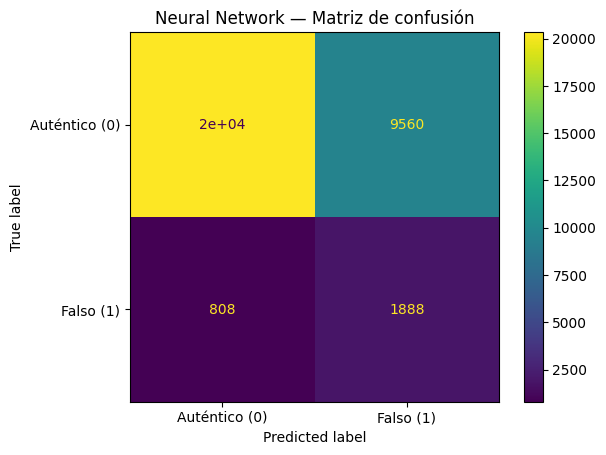

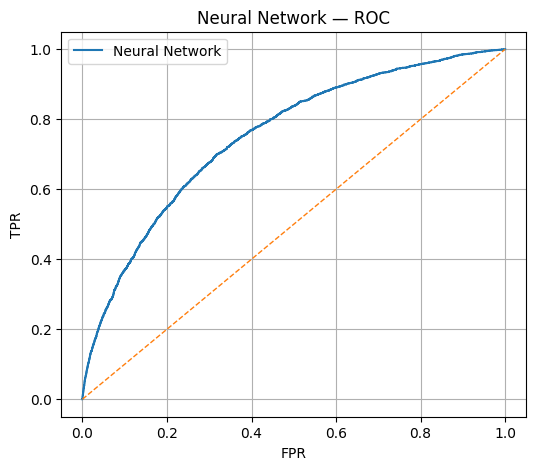

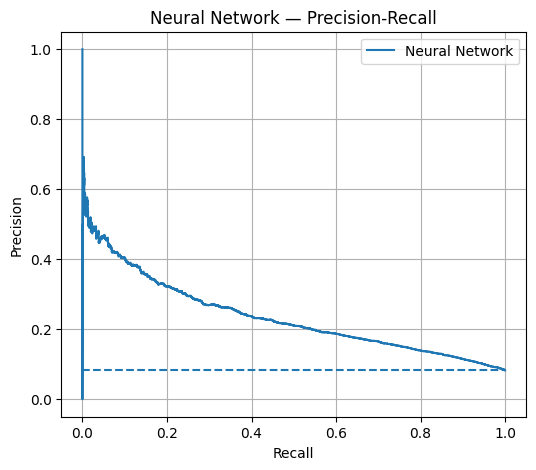

              precision    recall  f1-score   support

         0.0      0.962     0.680     0.797     29900
         1.0      0.165     0.700     0.267      2696

    accuracy                          0.682     32596
   macro avg      0.563     0.690     0.532     32596
weighted avg      0.896     0.682     0.753     32596



In [ ]:
y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
y_score_nn = model.predict(X_test)

acc_nn = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test, y_pred_nn, zero_division=0)
rec_nn = recall_score(y_test, y_pred_nn, zero_division=0)
f1_nn = f1_score(y_test, y_pred_nn, zero_division=0)
rocauc_nn = roc_auc_score(y_test, y_score_nn)
prauc_nn = average_precision_score(y_test, y_score_nn)

print('Neural Network — Métricas test')
print(f'Accuracy: {acc_nn:.3f}  Precision: {prec_nn:.3f}  Recall: {rec_nn:.3f}  F1: {f1_nn:.3f}')
print(f'ROC-AUC: {rocauc_nn:.3f}  PR-AUC: {prauc_nn:.3f}\n')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn, display_labels=['Auténtico (0)','Falso (1)'])
plt.title('Neural Network — Matriz de confusión'); plt.grid(False); plt.show()

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_score_nn)
plt.figure(figsize=(6,5)); plt.plot(fpr_nn, tpr_nn, label='Neural Network')
plt.plot([0,1],[0,1],'--', linewidth=1); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Neural Network — ROC'); plt.legend(); plt.grid(True); plt.show()

precision_nn, recall_nn, _ = precision_recall_curve(y_test, y_score_nn)
plt.figure(figsize=(6,5)); plt.plot(recall_nn, precision_nn, label='Neural Network')
baseline = (y_test==1).mean()
plt.hlines(baseline, 0, 1, linestyles='--')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Neural Network — Precision-Recall'); plt.legend(); plt.grid(True); plt.show()

print(classification_report(y_test, y_pred_nn, digits=3))

# Random Forest

In [ ]:
# ===== CALCULAMOS EL RANDOM FOREST CON DIFERENTES PARÁMETROS Y MIRAMOS CUAL ES EL MEJOR =====
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5],
    'class_weight': ['balanced']
}

gs_rf = GridSearchCV(rf, param_grid_rf, scoring='f1', cv=5, n_jobs=-1, refit=True)
gs_rf.fit(X_train, y_train)

print('Mejor F1 (cv):', round(gs_rf.best_score_, 3))
print('Mejores params:', gs_rf.best_params_)

Mejor F1 (cv): 0.254
Mejores params: {'class_weight': 'balanced', 'max_depth': 5, 'n_estimators': 200}


Random Forest — Métricas test
Accuracy: 0.681  Precision: 0.160  Recall: 0.670  F1: 0.258
ROC-AUC: 0.731  PR-AUC: 0.207



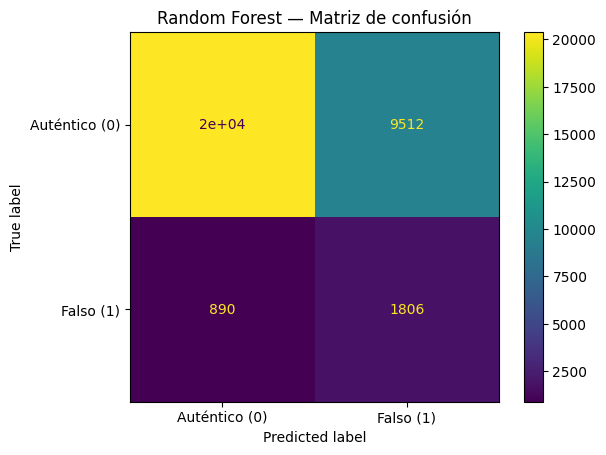

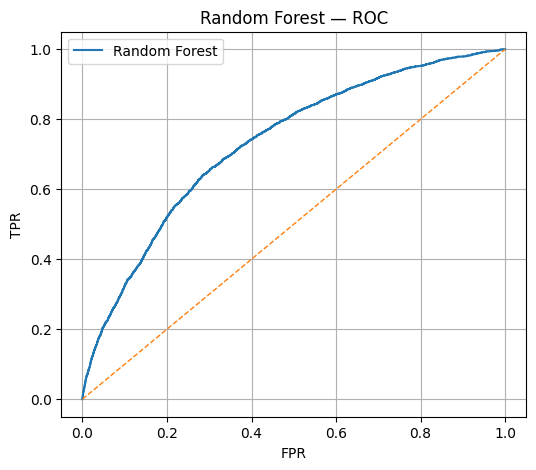

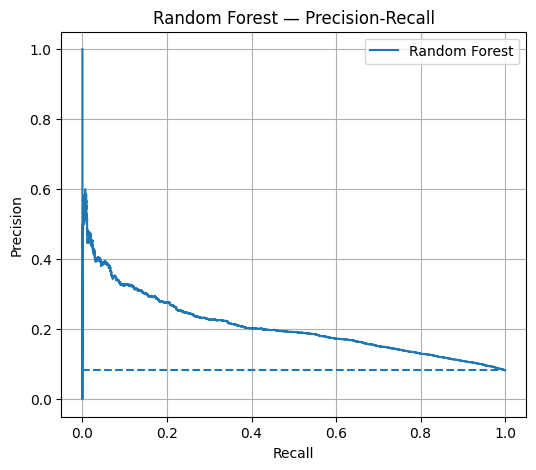

              precision    recall  f1-score   support

         0.0      0.958     0.682     0.797     29900
         1.0      0.160     0.670     0.258      2696

    accuracy                          0.681     32596
   macro avg      0.559     0.676     0.527     32596
weighted avg      0.892     0.681     0.752     32596



In [ ]:
best_rf = gs_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_score_rf = best_rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf, zero_division=0)
rec = recall_score(y_test, y_pred_rf, zero_division=0)
f1 = f1_score(y_test, y_pred_rf, zero_division=0)
rocauc = roc_auc_score(y_test, y_score_rf)
prauc = average_precision_score(y_test, y_score_rf)

print('Random Forest — Métricas test')
print(f'Accuracy: {acc:.3f}  Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}')
print(f'ROC-AUC: {rocauc:.3f}  PR-AUC: {prauc:.3f}\n')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['Auténtico (0)','Falso (1)'])
plt.title('Random Forest — Matriz de confusión'); plt.grid(False); plt.show()

fpr, tpr, _ = roc_curve(y_test, y_score_rf)
plt.figure(figsize=(6,5)); plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1],[0,1],'--', linewidth=1); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Random Forest — ROC'); plt.legend(); plt.grid(True); plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_score_rf)
plt.figure(figsize=(6,5)); plt.plot(recall, precision, label='Random Forest')
baseline = (y_test==1).mean()
plt.hlines(baseline, 0, 1, linestyles='--')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Random Forest — Precision-Recall'); plt.legend(); plt.grid(True); plt.show()

print(classification_report(y_test, y_pred_rf, digits=3))

# Resultados

Como hemos podido comprobar no han salido resultados muy buenos puesto que el data set estaba muy desbalanceado, en cualquier caso, podemos ver que la red neuronal ha sacado unos valores un poco mejores que el random forest.